In [1]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)

output_dir='/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'
base_path = "climt-long-runs/dry-land/regrid-data/"

Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2') 

/home/lab_project2/.conda/envs/xCDAT/lib/python3.13/site-packages/sympl/_core/dataarray.py:6: FutureWarning: xarray subclass DataArray should explicitly define __slots__
  class DataArray(xr.DataArray):


In [5]:
#dp=2000
#Lx=np.radians(2.8125)*6371*1000
#Ly=np.radians(2.79)*6371*1000

def compute_dse(ds, latc, lonc):
    # computes average DSE in the box between specified levels - units of J/kg
    
    p1=ds['air_pressure'].fillna(ds['surface_air_pressure'])
    at=ds['air_temperature'].fillna(ds['surface_temperature']).copy()
    at[:,1:]=(at.values[:,:-1]+at.values[:,1:])/2; at[:,0]=(at[:,0].values[:]+ds['surface_temperature'].values[:])/2
    p2=p1.copy()
    p2[:,1:]=p1[:,:-1].values[:]
    p2[:,0]=ds['surface_air_pressure'].values[:]
    
    lat_rad=np.radians(ds['air_temperature'].lat)
    
    z=(Rd*at/g*np.log(p2/p1)).cumsum(dim='lev')
    dse=(Cp*ds['air_temperature']+g*z).sel({'lat':slice(latc+5,latc-5),
                                            'lon':slice(lonc-5,lonc+5),'lev':slice(98000, 90000)}).weighted(np.cos(lat_rad))
    return dse.mean(dim=('lat', 'lon','lev'))

def compute_dse_tend(ds, latc, lonc):
    # computes average DSE tendency in the box between specified levels - units of J/kg
    
    p1=ds['air_pressure'].fillna(ds['surface_air_pressure'])
    at=ds['air_temperature'].fillna(ds['surface_temperature']).copy()
    at[:,1:]=(at.values[:,:-1]+at.values[:,1:])/2; at[:,0]=(at[:,0].values[:]+ds['surface_temperature'].values[:])/2
    p2=p1.copy()
    p2[:,1:]=p1[:,:-1].values[:]
    p2[:,0]=ds['surface_air_pressure'].values[:]
    
    lat_rad=np.radians(ds['air_temperature'].lat)
    
    z=(Rd*at/g*np.log(p2/p1)).cumsum(dim='lev')
    dse=Cp*ds['air_temperature']+g*z
    dsew=metpy.calc.first_derivative(dse, axis='lev')/units.metre
    dsex=metpy.calc.first_derivative(dse, axis='lon')
    dsey=metpy.calc.first_derivative(dse, axis='lat')
    dse_tend=-dsex*ds['eastward_wind']-dsey*ds['northward_wind']-dsew*ds['vertical_wind']
    dse_tend=(dse_tend).sel({'lat':slice(latc+5,latc-5),
                             'lon':slice(lonc-5,lonc+5),'lev':slice(98000, 90000)}).weighted(np.cos(lat_rad))
    
    return dse_tend.mean(dim=('lat', 'lon','lev'))*86400

In [ ]:
latc=45
output_file=output_dir+'hw_'+str(latc)
with open(output_file, 'rb') as f:
    hw_master=pickle.load(f)
    
target_lons = np.arange(5, 355, 70)

mask = [lon in target_lons for lon in hw_master['lonc']]
hw_master = {key: [vals[i] for i, m in enumerate(mask) if m]
               for key, vals in hw_master.items()}
    
hw_index=1

y=1
loop=0
dse_master={'index':[], 'T':[], 'lonc':[], 'dse_low':[], 'dse_tend_low':[],
              'intensity':[], 'duration':[], 'maximum':[]}

full_length=len(hw_master['index'])

while hw_index<=full_length:
    r=hw_master['run'][hw_index-1]
    zarr_path = base_path+"run"+str(r)+"/year"+str(y)
    ds = xr.open_zarr(fs.get_mapper(zarr_path))

    while(True):
        time_slice=hw_master['time'][hw_index-1]
        try:
            ds_hw=ds.sel({'time':time_slice})
            print(hw_index);loop=0
            
            dse_low=compute_dse(ds_hw, latc, hw_master['lonc'][hw_index-1])
            dse_tend_low=compute_dse_tend(ds_hw, latc, hw_master['lonc'][hw_index-1])
            dse_master['dse_low'].append(dse_low.values)
            dse_master['dse_tend_low'].append(dse_tend_low.values)
            for e in hw_master.keys():
                if e in dse_master.keys():
                    dse_master[e].append(hw_master[e][hw_index-1])
            
            hw_index=hw_index+1
            if hw_index>full_length:
                break
        except KeyError:
            loop=loop+1
            if loop>20:
                print('skipping!')
                hw_index=hw_index+1
                loop=0
                break
            if y<20:
                y=y+1
            else:
                y=1
            break
            
output_file=output_dir+'dse_mean_'+str(latc)
if not os.path.isfile(output_file):
    with open(output_file, 'wb') as f:
        pickle.dump(dse_master, f)

 
0.001031 x - 13.59
 
1.28 x + 181.1


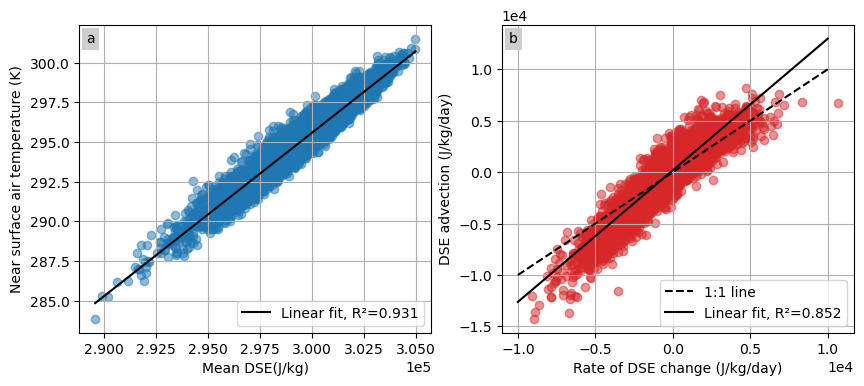

In [2]:
#plotting the graphs from the mean dse instead of summed dse

latc=45
output_file = output_dir+'dse_mean_'+str(latc)
with open(output_file, 'rb') as f:
    dse_master= pickle.load(f)
    
output_file = output_dir+'thresh95'
with open(output_file, 'rb') as f:
    thresh = pickle.load(f)
thresh_val= thresh[latc]  

dse_values = {'dse_diff':[], 'dse_tend':[], 'dse_low':[], 'T':[]}
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    T = dse_master['T'][i]
    dse=dse_master['dse_tend_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    dse_tend=((dse[1:]+dse[:-1])/2)
    
    dse_values['dse_diff'].append(dse_diff)
    dse_values['dse_tend'].append(dse_tend)
    dse_values['dse_low'].append(dse_low)
    dse_values['T'].append(T)


temp = np.concatenate(dse_values['T']) + thresh_val
dse = np.concatenate(dse_values['dse_low'])
dse_diff=np.concatenate(dse_values['dse_diff'])
dse_tend=np.concatenate(dse_values['dse_tend'])

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(1, 2)
fig=pl.figure(figsize=(10,4))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 

####################### dse vs temp #######################################

ax1.scatter(dse, temp, alpha=0.5)
ax1.grid(True)
x=dse
y=temp
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

ax1.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax1.legend(loc='lower right')
set_label(fig, ax1, 'a')
ax1.set_xlabel('Mean DSE(J/kg)')
ax1.set_ylabel('Near surface air temperature (K)')
ax1.xaxis.set_major_formatter(formatter)

################### tendency vs advection #################################

ax2.scatter(dse_diff, dse_tend, c='#d72728',alpha=0.5)
ax2.grid(True)
val = 1e4
xy=np.array([-1,0,1])*val
ax2.plot(xy, xy,color='k', linestyle='--', label='1:1 line')  

x = dse_diff
y = dse_tend
#Linear regression
coeffs = np.polyfit(x, y, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(-val, val, 200)
y_fit = fit_fn(x_fit)
print(fit_fn)

y_pred = fit_fn(x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax2.plot(x_fit, y_fit, 'k', label=f'Linear fit, R²={r2:.3f}')
ax2.set_xlabel('Rate of DSE change (J/kg/day)')
ax2.set_ylabel('DSE advection (J/kg/day)')
ax2.legend(loc='lower right')
set_label(fig, ax2, 'b')
ax2.xaxis.set_major_formatter(formatter)
ax2.yaxis.set_major_formatter(formatter)

#fig.savefig('/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/3.pdf', bbox_inches='tight')
#fig.savefig('/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/3.jpg',dpi=600, bbox_inches='tight')